# Textbook

## DMD operator

In [4]:
import numpy as np

def dmd(X1, X2, r, dt):
    """
    Dynamic Mode Decomposition (DMD) algorithm.
    Args:
        X1: Data matrix (n_features, n_snapshots-1)
        X2: Shifted data matrix (n_features, n_snapshots-1)
        r: Target rank for truncation
        dt: Time step between snapshots
    Returns:
        Phi: DMD modes
        omega: Continuous-time DMD eigenvalues
        lam: Discrete-time DMD eigenvalues
        b: Mode amplitudes
        X_dmd: DMD reconstruction
    """
    # SVD: Decompose X1 to get dominant modes (least-squares optimal basis)
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)
    U_r = U[:, :r]  # Truncate to rank-r
    S_r = np.diag(S[:r])
    V_r = Vh.conj().T[:, :r]
    # Build low-rank dynamics in reduced space
    A_tilde = U_r.T @ X2 @ V_r @ np.linalg.inv(S_r)
    # Eigendecomposition of reduced operator
    D, W_r = np.linalg.eig(A_tilde)  # D: eigenvalues, W_r: eigenvectors
    # Compute DMD modes
    Phi = X2 @ V_r @ np.linalg.inv(S_r) @ W_r
    # Discrete and continuous eigenvalues
    lam = D  # D is already a 1D array of eigenvalues
    omega = np.log(lam) / dt
    # Least-squares fit for initial amplitudes
    x1 = X1[:, 0]
    b = np.linalg.lstsq(Phi, x1, rcond=None)[0]
    m = X1.shape[1]
    t = np.arange(m) * dt
    time_dynamics = np.zeros((r, m), dtype=complex)
    for i in range(m):
        time_dynamics[:, i] = b * np.exp(omega * t[i])
    X_dmd = Phi @ time_dynamics
    return Phi, omega, lam, b, X_dmd


**Approximation in the Applied DMD:**

- The standard DMD algorithm uses the least-squares approach to find the best-fit linear operator $A$ and the mode amplitudes $b$. This is because the Moore–Penrose pseudoinverse (used in the algorithm) minimizes the sum of squared errors between predicted and actual data.
- In principle, other fitting criteria (e.g., robust regression, L1 minimization) could be used, but the classic DMD is based on **least-squares** for mathematical convenience and computational efficiency.
- In the code, the least-squares approximation appears in:
  - The use of SVD (Singular Value Decomposition) to project data onto a low-rank subspace (minimizing reconstruction error).
  - The computation of $b$ using `np.linalg.lstsq(Phi, x1, rcond=None)[0]`, which solves $x_1 = \Phi b$ in the least-squares sense.

**Shape of DMD Outputs and Rank Selection:**

- The eigenvalues (`lam`, `omega`) and mode amplitudes (`b`) are 1D arrays, each of length equal to the chosen rank `r`. The DMD modes (`Phi`) are 2D (n_features × r).
- The rank `r` determines how many dynamic modes are retained. Choosing `r`:
  - **Singular Value Decay:** Plot the singular values of the data matrix (from SVD). Choose `r` where the singular values drop off sharply (the "elbow"), keeping modes above the noise floor.
  - **Energy Criterion:** Retain enough modes to capture a desired percentage (e.g., 99%) of the total energy (sum of squared singular values).
  - **Physical Insight:** Use prior knowledge about the system (e.g., number of dominant frequencies or structures).
- Too low a rank may miss important dynamics; too high may include noise.


**Explanation of DMD Outputs:**

- **Phi**: DMD modes (spatial patterns) that describe coherent structures in the data.
- **omega**: Continuous-time eigenvalues, giving the growth/decay rates and frequencies of the modes.
- **lam**: Discrete-time eigenvalues, related to omega by $\lambda = e^{\omega \Delta t}$.
- **b**: Mode amplitudes, representing the initial contribution of each mode.
- **X_dmd**: DMD reconstruction of the data, i.e., the time evolution of the system using the identified modes and dynamics.


**About `b` (Mode Amplitudes):**

The vector `b` contains the amplitudes of the DMD modes at the initial time. It is computed by solving $x_1 = \Phi b$ (see Eq. (1.25) in the textbook), where $x_1$ is the first snapshot and $\Phi$ is the matrix of DMD modes. This gives the best-fit (in the least-squares sense) initial contribution of each mode to reconstruct the system's state at $t=0$.


**DMD Assumptions:**

- DMD approximates the original (possibly nonlinear) dynamics with a best-fit linear model: $x_{k+1} \approx A x_k$.
- The method assumes the data can be well-approximated by a low-rank linear system over the sampling window.
- The approximation is optimal in the least-squares sense (minimizing the Frobenius norm of the error between predicted and actual snapshots).
- DMD uses SVD for dimensionality reduction, projecting the dynamics onto a low-dimensional subspace (POD modes).
- The method does not require knowledge of the underlying equations—only data snapshots are needed (equation-free, data-driven approach).

## Application 1: Reconstruction

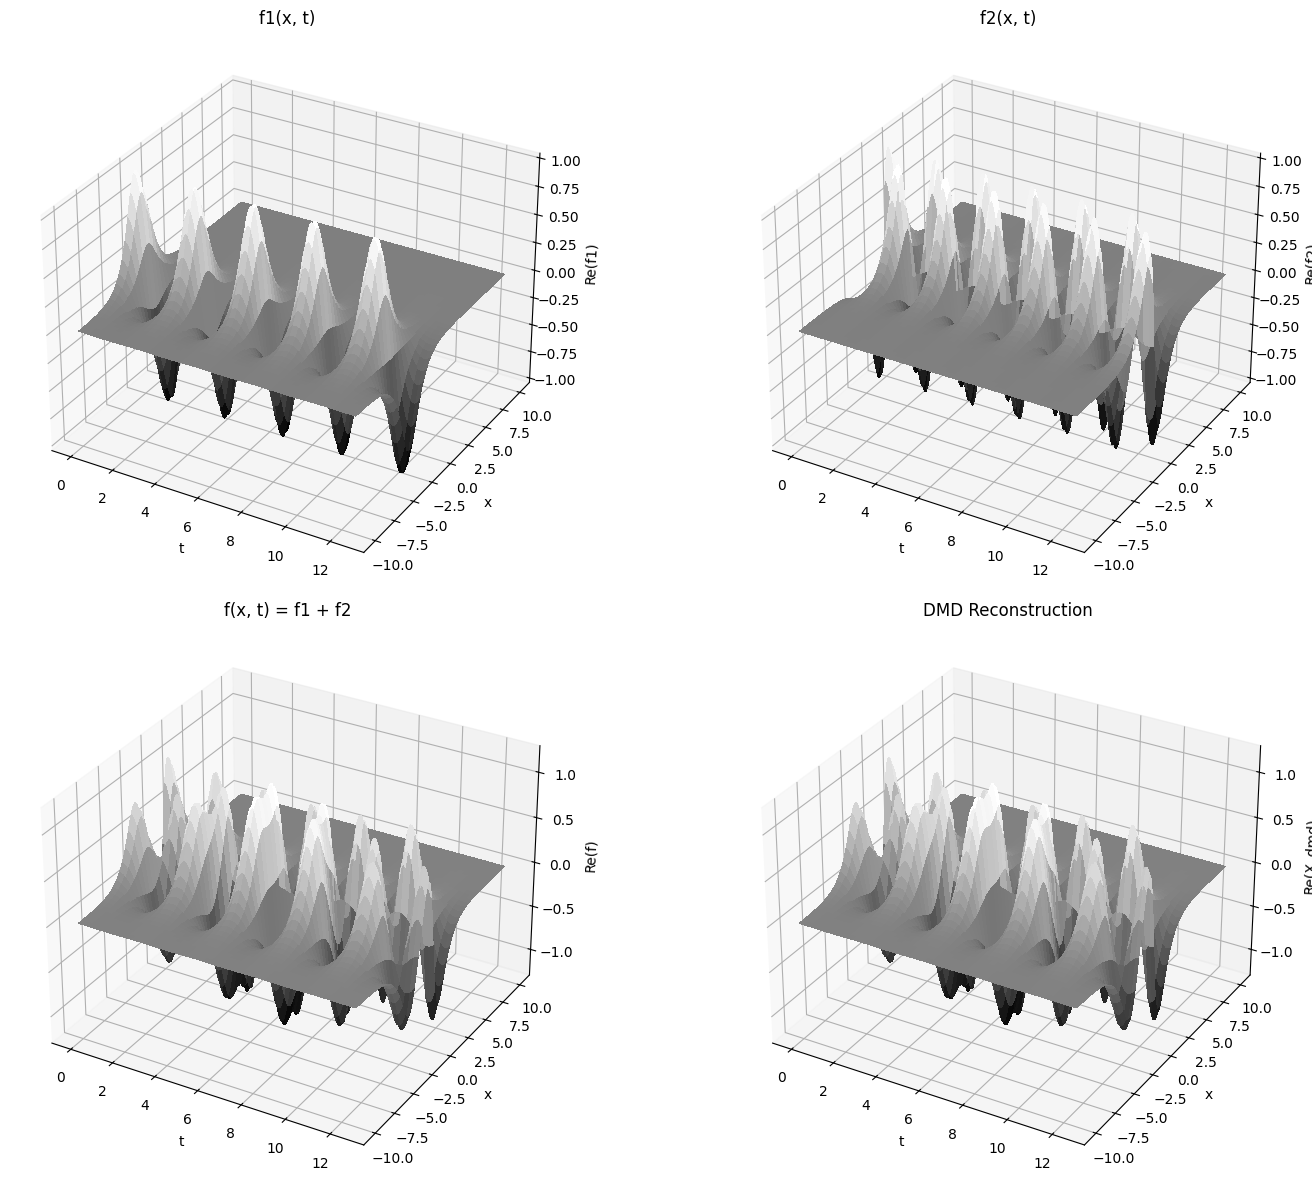

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def sech(x):
    return 1 / np.cosh(x)

# Define space and time grids
xi = np.linspace(-10, 10, 400)
t = np.linspace(0, 4 * np.pi, 200)
dt = t[1] - t[0]
Xgrid, T = np.meshgrid(xi, t)

# Create two spatiotemporal patterns
f1 = sech(Xgrid + 3) * np.exp(1j * 2.3 * T)
f2 = (sech(Xgrid) * np.tanh(Xgrid)) * (2 * np.exp(1j * 2.8 * T))

# Combine signals and make data matrix
f = f1 + f2
X = f.T  # Data matrix: each column is a snapshot in time

# Prepare DMD data matrices
X1 = X[:, :-1]
X2 = X[:, 1:]
r = 2
Phi, omega, lam, b, X_dmd = dmd(X1, X2, r, dt)

# Prepare for 3D plotting
fig = plt.figure(figsize=(16, 12))

# f1(x, t)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(T, Xgrid, np.real(f1), cmap='gray', linewidth=0, antialiased=False)
ax1.set_title('f1(x, t)')
ax1.set_xlabel('t')
ax1.set_ylabel('x')
ax1.set_zlabel('Re(f1)')

# f2(x, t)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot_surface(T, Xgrid, np.real(f2), cmap='gray', linewidth=0, antialiased=False)
ax2.set_title('f2(x, t)')
ax2.set_xlabel('t')
ax2.set_ylabel('x')
ax2.set_zlabel('Re(f2)')

# f(x, t) = f1 + f2
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot_surface(T, Xgrid, np.real(f), cmap='gray', linewidth=0, antialiased=False)
ax3.set_title('f(x, t) = f1 + f2')
ax3.set_xlabel('t')
ax3.set_ylabel('x')
ax3.set_zlabel('Re(f)')

# DMD Reconstruction
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# Use only the matching time steps for DMD output
ax4.plot_surface(T[:-1, :], Xgrid[:-1, :], np.real(X_dmd.T), cmap='gray', linewidth=0, antialiased=False)
ax4.set_title('DMD Reconstruction')
ax4.set_xlabel('t')
ax4.set_ylabel('x')
ax4.set_zlabel('Re(X_dmd)')

plt.tight_layout()
plt.show()

**Application 1: DMD Reconstruction and Rank Selection**

In Application 1, the DMD algorithm is used to decompose and reconstruct a mixture of two spatiotemporal signals (see the 3D plots). The DMD reconstruction (bottom right plot) closely matches the original mixed signal, demonstrating that DMD can extract the dominant dynamic modes and reconstruct the system's evolution.

The rank parameter `r=2` (see `r = 2` in the code) is chosen because the data is generated from two underlying signals (see the construction of `f1` and `f2`). This matches the number of dominant modes present, allowing DMD to capture all essential dynamics and achieve a nearly perfect reconstruction.

In [24]:
omega

array([-9.16420437e-15+2.8j, -1.18220034e-14+2.3j])

textbook:
omega =
0.0000 + 2.8000i
0.0000 + 2.3000i

## Application 2: Decompose to Singular

In [27]:
def align_modes(true_modes, test_modes):
    aligned = np.zeros((2, test_modes.shape[0]))
    used = []
    for i in range(2):
        corrs = [np.abs(np.corrcoef(true_modes[i], test_modes[:, j])[0, 1]) if j not in used else -np.inf for j in range(test_modes.shape[1])]
        j_best = np.argmax(corrs)
        sign = np.sign(np.dot(true_modes[i], test_modes[:, j_best]))
        aligned[i] = sign * test_modes[:, j_best]
        used.append(j_best)
    return aligned

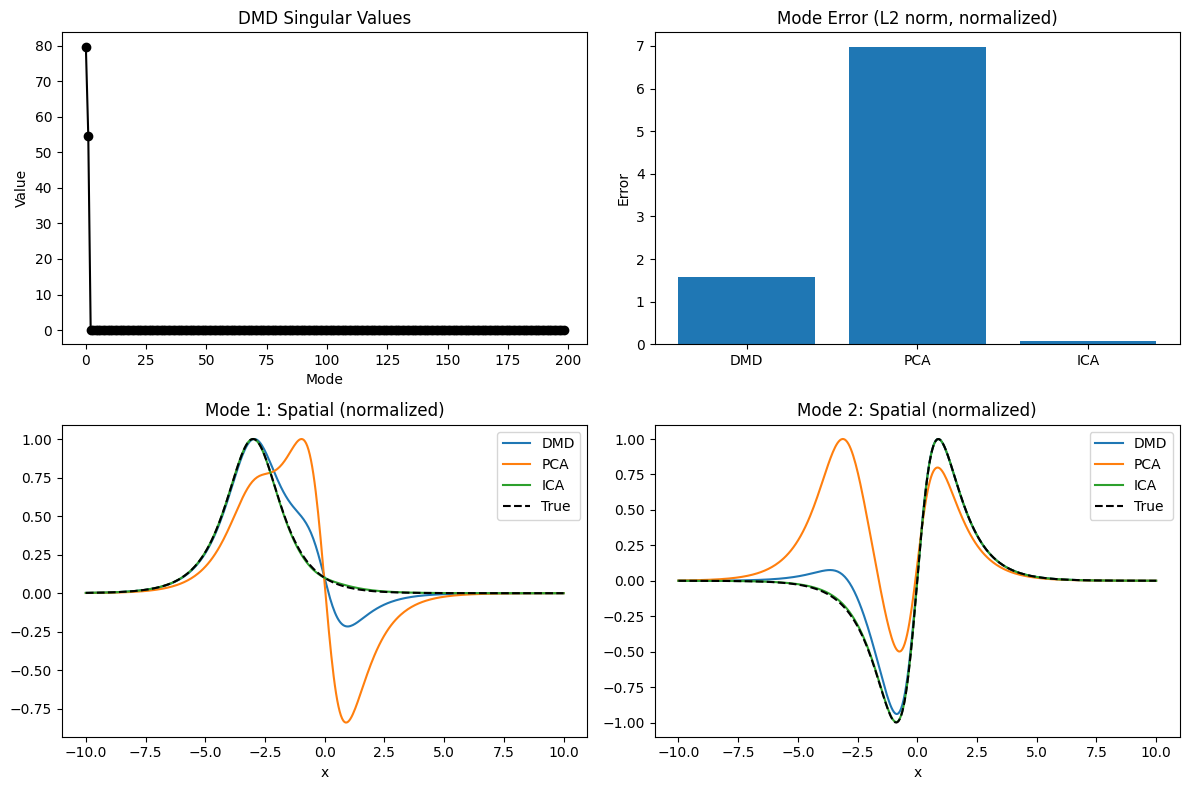

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

def sech(x):
    return 1 / np.cosh(x)

# 1. Generate data: two separable spatiotemporal signals (TRUE DATA DEFINITION ONLY DIFFERS FROM APP 3)
xi = np.linspace(-10, 10, 400)
t = np.linspace(0, 4 * np.pi, 200)
dt = t[1] - t[0]
Xgrid, T = np.meshgrid(xi, t)

# True spatial and temporal modes (Application 2: stationary modes)
true_spatial1 = sech(xi + 3)
true_spatial2 = sech(xi) * np.tanh(xi)
true_temporal1 = np.real(np.exp(1j * 2.3 * t))
true_temporal2 = np.real(2 * np.exp(1j * 2.8 * t))

# Construct signals
f1 = np.outer(true_temporal1, true_spatial1)
f2 = np.outer(true_temporal2, true_spatial2)
f = f1 + f2
X = f.T  # Each column is a snapshot in time

# 2. DMD decomposition (use textbook DMD function)
def run_dmd(X, r, dt):
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)
    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    V_r = Vh.conj().T[:, :r]
    A_tilde = U_r.T @ X2 @ V_r @ np.linalg.inv(S_r)
    D, W_r = np.linalg.eig(A_tilde)
    Phi = X2 @ V_r @ np.linalg.inv(S_r) @ W_r
    lam = D
    omega = np.log(lam) / dt
    x1 = X1[:, 0]
    b = np.linalg.lstsq(Phi, x1, rcond=None)[0]
    m = X1.shape[1]
    t_dyn = np.arange(m) * dt
    time_dynamics = np.zeros((r, m), dtype=complex)
    for i in range(m):
        time_dynamics[:, i] = b * np.exp(omega * t_dyn[i])
    X_dmd = Phi @ time_dynamics
    return Phi, omega, lam, b, X_dmd, S

r = 2
Phi, omega, lam, b, X_dmd, S = run_dmd(X, r, dt)

# 3. PCA decomposition (SVD)
U, S_pca, Vh = np.linalg.svd(X, full_matrices=False)
pca_spatial = U[:, :2].T  # shape (2, features)
pca_temporal = Vh[:2, :]  # shape (2, snapshots)

# 4. ICA decomposition (FastICA)
ica = FastICA(n_components=2)
IC = ica.fit_transform(np.real(X).T)  # shape (snapshots, components)
A_ = ica.mixing_  # shape (features, components)
ica_spatial = A_.T  # shape (2, features)
ica_temporal = IC.T  # shape (2, snapshots)

# 5. Align DMD, PCA, and ICA spatial modes to true modes by maximizing correlation
dmd_spatial_aligned = align_modes([true_spatial1, true_spatial2], np.real(Phi))
pca_spatial_aligned = align_modes([true_spatial1, true_spatial2], pca_spatial.T)
ica_spatial_aligned = align_modes([true_spatial1, true_spatial2], ica_spatial.T)

def norm_mode(mode):
    return mode / np.max(np.abs(mode))

dmd_spatial_norm = np.array([norm_mode(dmd_spatial_aligned[0]), norm_mode(dmd_spatial_aligned[1])])
pca_spatial_norm = np.array([norm_mode(pca_spatial_aligned[0]), norm_mode(pca_spatial_aligned[1])])
ica_spatial_norm = np.array([norm_mode(ica_spatial_aligned[0]), norm_mode(ica_spatial_aligned[1])])
true_spatial_norm = np.array([norm_mode(true_spatial1), norm_mode(true_spatial2)])

# 6. Compute L2 errors (spatial modes, normalized)
err_dmd = [np.linalg.norm(true_spatial_norm[0] - dmd_spatial_norm[0]), np.linalg.norm(true_spatial_norm[1] - dmd_spatial_norm[1])]
err_pca = [np.linalg.norm(true_spatial_norm[0] - pca_spatial_norm[0]), np.linalg.norm(true_spatial_norm[1] - pca_spatial_norm[1])]
err_ica = [np.linalg.norm(true_spatial_norm[0] - ica_spatial_norm[0]), np.linalg.norm(true_spatial_norm[1] - ica_spatial_norm[1])]

# 7. Plot results (ignore temporal plots for now)
plt.figure(figsize=(12, 8))

# (a) DMD Singular values
plt.subplot(2, 2, 1)
plt.plot(S, 'ko-')
plt.title('DMD Singular Values')
plt.xlabel('Mode')
plt.ylabel('Value')

# (b) Mode error
plt.subplot(2, 2, 2)
plt.bar(['DMD', 'PCA', 'ICA'], [np.mean(err_dmd), np.mean(err_pca), np.mean(err_ica)])
plt.title('Mode Error (L2 norm, normalized)')
plt.ylabel('Error')

# (c) Mode 1: Spatial (normalized)
plt.subplot(2, 2, 3)
plt.plot(xi, dmd_spatial_norm[0], label='DMD')
plt.plot(xi, pca_spatial_norm[0], label='PCA')
plt.plot(xi, ica_spatial_norm[0], label='ICA')
plt.plot(xi, true_spatial_norm[0], label='True', linestyle='dashed', color = 'k')
plt.title('Mode 1: Spatial (normalized)')
plt.xlabel('x')
plt.legend()

# (d) Mode 2: Spatial (normalized)
plt.subplot(2, 2, 4)
plt.plot(xi, dmd_spatial_norm[1], label='DMD')
plt.plot(xi, pca_spatial_norm[1], label='PCA')
plt.plot(xi, ica_spatial_norm[1], label='ICA')
plt.plot(xi, true_spatial_norm[1], label='True', linestyle='dashed', color = 'k')
plt.title('Mode 2: Spatial (normalized)')
plt.xlabel('x')
plt.legend()

plt.tight_layout()
plt.show()

**Application 2: Comparison of DMD, PCA, and ICA**

In this application, we compare the ability of DMD, PCA, and ICA to extract the true spatiotemporal modes from the mixed signal. DMD achieves a nearly perfect match with the true modes, while ICA performs better than PCA but is not exact. The singular value plot shows that a rank-2 truncation is appropriate, and the error plot quantifies the accuracy of each method.

**Why can the data be divided into temporal and spatial modes?**

The data is generated as a sum of separable spatiotemporal signals:
$$f(x, t) = f_1(x, t) + f_2(x, t)$$
where each component is a product of a spatial function and a temporal function:
$$f_1(x, t) = \text{sech}(x+3) \cdot e^{i \omega_1 t}$$
$$f_2(x, t) = \text{sech}(x) \tanh(x) \cdot 2 e^{i \omega_2 t}$$

This separability means the data matrix can be decomposed into spatial modes (functions of $x$) and temporal modes (functions of $t$). Methods like DMD, PCA, and ICA exploit this structure to extract the dominant spatial and temporal patterns. DMD, in particular, is designed to identify coherent structures that evolve linearly in time, making it especially effective for data with separable spatiotemporal dynamics.

## Application 3: Translational Factor

In [12]:
def align_modes(true_modes, test_modes):
    aligned = np.zeros((2, test_modes.shape[0]))
    used = []
    for i in range(2):
        corrs = [np.abs(np.corrcoef(true_modes[i], test_modes[:, j])[0, 1]) if j not in used else -np.inf for j in range(test_modes.shape[1])]
        j_best = np.argmax(corrs)
        sign = np.sign(np.dot(true_modes[i], test_modes[:, j_best]))
        aligned[i] = sign * test_modes[:, j_best]
        used.append(j_best)
    return aligned


The above code does not alter the original mode shapes; instead, it:

1. Finds the best matching reconstructed mode for each true mode (by correlation).
2. Adjusts the sign so the peaks align (using dot product).
3. Returns the reordered and sign-adjusted reconstructed modes.

/tmp/ipykernel_466263/4288676211.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  aligned[i] = sign * test_modes_clip[j_best]


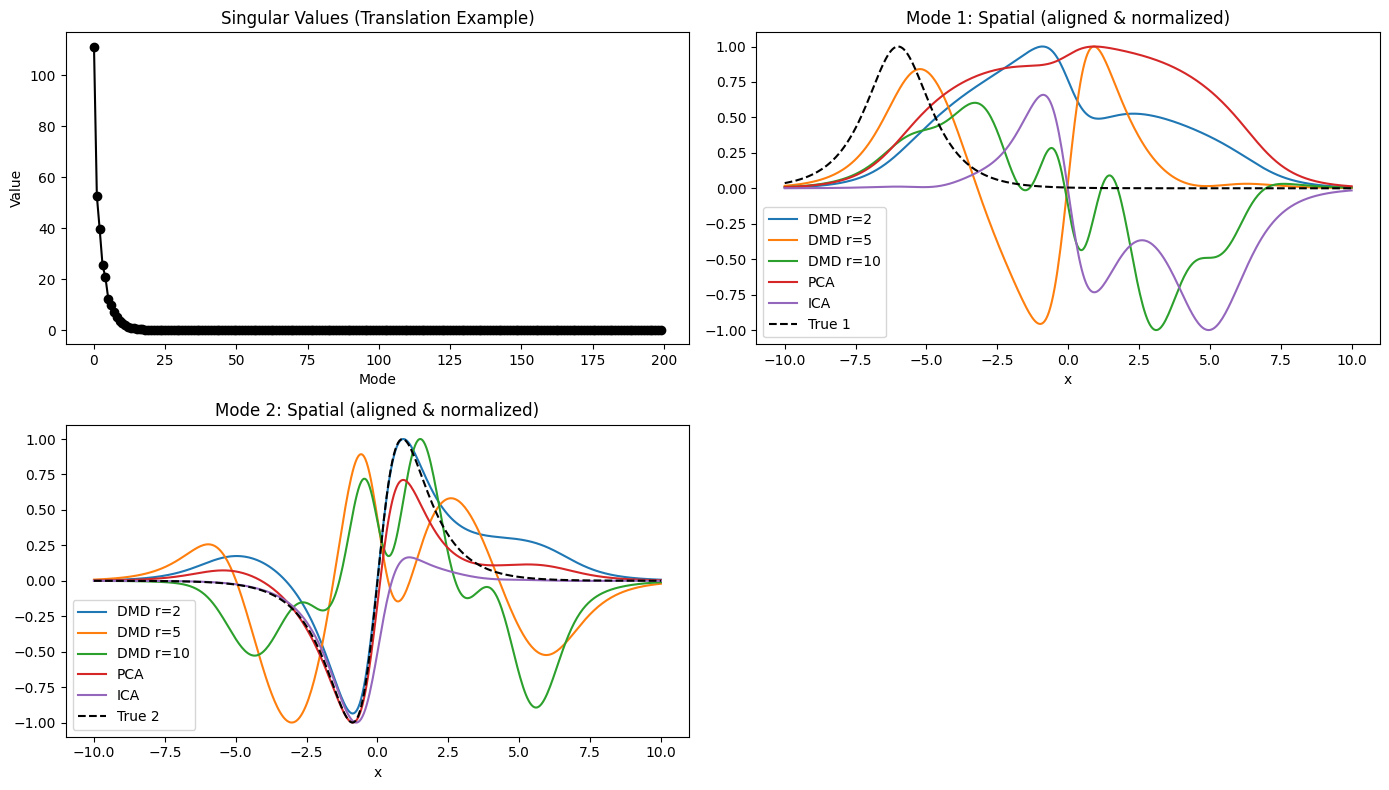

In [22]:
# Application 3: Translational invariance example (textbook Eq. 1.34)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

def sech(x):
    return 1 / np.cosh(x)

# 1. Generate data: one translating, one stationary mode
xi = np.linspace(-10, 10, 400)
t = np.linspace(0, 4 * np.pi, 200)
dt = t[1] - t[0]
Xgrid, T = np.meshgrid(xi, t)

# Translating mode: sech(x + 6 - t) * exp(i*2.3*t)
true_spatial1 = sech(xi + 6)
true_spatial2 = sech(xi) * np.tanh(xi)
f1 = sech(Xgrid + 6 - t[:, None]) * np.exp(1j * 2.3 * T)
f2 = (sech(Xgrid) * np.tanh(Xgrid)) * (2 * np.exp(1j * 2.8 * T))
f = f1 + f2
X = f.T  # Each column is a snapshot in time

# 2. DMD decomposition (try rank-2, rank-5, rank-10)
def run_dmd(X, r, dt):
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)
    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    V_r = Vh.conj().T[:, :r]
    A_tilde = U_r.T @ X2 @ V_r @ np.linalg.inv(S_r)
    D, W_r = np.linalg.eig(A_tilde)
    Phi = X2 @ V_r @ np.linalg.inv(S_r) @ W_r
    lam = D
    omega = np.log(lam) / dt
    x1 = X1[:, 0]
    b = np.linalg.lstsq(Phi, x1, rcond=None)[0]
    m = X1.shape[1]
    t_dyn = np.arange(m) * dt
    time_dynamics = np.zeros((r, m), dtype=complex)
    for i in range(m):
        time_dynamics[:, i] = b * np.exp(omega * t_dyn[i])
    X_dmd = Phi @ time_dynamics
    return Phi, omega, lam, b, X_dmd, S

# 3. PCA decomposition (SVD)
U, S, Vh = np.linalg.svd(X, full_matrices=False)
pca_spatial = U[:, :10].T  # up to 10 modes
pca_temporal = Vh[:10, :]

# 4. ICA decomposition (FastICA)
ica = FastICA(n_components=10)
IC = ica.fit_transform(np.real(X).T)  # shape (snapshots, components)
A_ = ica.mixing_  # shape (features, components)
ica_spatial = A_.T  # shape (10, features)
ica_temporal = IC.T  # shape (10, snapshots)

# 5. DMD for r=2, 5, 10
Phi2, omega2, lam2, b2, X_dmd2, S2 = run_dmd(X, 2, dt)
Phi5, omega5, lam5, b5, X_dmd5, S5 = run_dmd(X, 5, dt)
Phi10, omega10, lam10, b10, X_dmd10, S10 = run_dmd(X, 10, dt)

# Align modes to true modes by maximizing correlation
true_modes = [true_spatial1, true_spatial2]

# Align and normalize DMD modes
Phi2_aligned = align_modes(true_modes, np.real(Phi2))
Phi5_aligned = align_modes(true_modes, np.real(Phi5))
Phi10_aligned = align_modes(true_modes, np.real(Phi10))
# Align and normalize PCA and ICA modes
pca_aligned = align_modes(true_modes, pca_spatial.T)
ica_aligned = align_modes(true_modes, ica_spatial.T)

def norm_mode(mode):
    return mode / np.max(np.abs(mode))

Phi2_norm = np.array([norm_mode(Phi2_aligned[0]), norm_mode(Phi2_aligned[1])])
Phi5_norm = np.array([norm_mode(Phi5_aligned[0]), norm_mode(Phi5_aligned[1])])
Phi10_norm = np.array([norm_mode(Phi10_aligned[0]), norm_mode(Phi10_aligned[1])])
pca_norm = np.array([norm_mode(pca_aligned[0]), norm_mode(pca_aligned[1])])
ica_norm = np.array([norm_mode(ica_aligned[0]), norm_mode(ica_aligned[1])])
true_norm = np.array([norm_mode(true_spatial1), norm_mode(true_spatial2)])

# 6. Plot singular values
plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.plot(S, 'ko-')
plt.title('Singular Values (Translation Example)')
plt.xlabel('Mode')
plt.ylabel('Value')

# 7. Plot spatial modes (aligned and normalized)
plt.subplot(2, 2, 2)

plt.plot(xi, Phi2_norm[0], label='DMD r=2')
plt.plot(xi, Phi5_norm[0], label='DMD r=5')
plt.plot(xi, Phi10_norm[0], label='DMD r=10')
plt.plot(xi, pca_norm[0], label='PCA')
plt.plot(xi, ica_norm[0], label='ICA')
plt.plot(xi, true_norm[0], label='True 1', linestyle='dashed', color='k')
plt.title('Mode 1: Spatial (aligned & normalized)')
plt.xlabel('x')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(xi, Phi2_norm[1], label='DMD r=2')
plt.plot(xi, Phi5_norm[1], label='DMD r=5')
plt.plot(xi, Phi10_norm[1], label='DMD r=10')
plt.plot(xi, pca_norm[1], label='PCA')
plt.plot(xi, ica_norm[1], label='ICA')
plt.plot(xi, true_norm[1], label='True 2', linestyle='dashed', color='k')
plt.title('Mode 2: Spatial (aligned & normalized)')
plt.xlabel('x')
plt.legend()

plt.tight_layout()
plt.show()

**Singular Values: Meaning and Diagnostic Use**
- Singular values (from SVD) measure the strength or energy of each mode in the data matrix. Large singular values correspond to dominant patterns, while small ones indicate noise or less important features.
- Plotting singular values helps diagnose the data structure:
    - A sharp drop ("elbow") suggests a natural cutoff for the number of significant modes (rank selection).
    - A slow decay or many small values may indicate noise or complex dynamics.
- In DMD and PCA, singular value plots guide how many modes to keep for accurate reconstruction and help avoid overfitting to noise.